In [1]:
import xgboost
print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.4.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/raw/final_dataset.csv")

# Convert date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Convert price
df["Modal_Price"] = pd.to_numeric(
    df["Modal_Price"],
    errors="coerce"
)

# Sort data
df = df.sort_values("Date")

# Remove missing values
df = df.dropna(
    subset=["Date", "Modal_Price"]
)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nCommodities:")
print(df["Commodity"].unique())

Dataset shape: (54340, 28)

Columns:
['State', 'Commodity_Group', 'Commodity', 'Date', 'Arrival', 'Arrival_Unit', 'Modal_Price', 'Price_Unit', 'District', 'Max_Temp', 'Min_Temp', 'Rainfall_mm', 'Rain_mm', 'WindSpeed', 'Festival', 'Holiday', 'Month', 'Year', 'Day', 'Weekend', 'DayOfWeek', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_7', 'Rolling_30', 'Price_Change']

Date range:
2023-01-01 00:00:00 to 2025-12-31 00:00:00

Commodities:
<ArrowStringArray>
['Onion', 'Wheat', 'Tomato', 'Potato', 'Rice']
Length: 5, dtype: str


In [19]:
# ==============================================================
# STEP 4 — PREPARE ALL 5 COMMODITIES
# ==============================================================

commodities = [
    "Onion",
    "Potato",
    "Tomato",
    "Rice",
    "Wheat"
]

commodity_daily = {}

for commodity in commodities:

    # Select commodity
    temp = df[df["Commodity"] == commodity].copy()

    # Ensure correct data types
    temp["Date"] = pd.to_datetime(
        temp["Date"],
        errors="coerce"
    )

    temp["Modal_Price"] = pd.to_numeric(
        temp["Modal_Price"],
        errors="coerce"
    )

    # Remove invalid values
    temp = temp.dropna(
        subset=["Date", "Modal_Price"]
    )

    # Create one average price per date
    daily = (
        temp.groupby("Date")["Modal_Price"]
        .mean()
        .reset_index()
    )

    # Sort by date
    daily = daily.sort_values(
        "Date"
    ).reset_index(drop=True)

    # Store
    commodity_daily[commodity] = daily

    print("=" * 60)
    print(commodity)
    print("=" * 60)

    print("Rows:", len(daily))
    print(
        "Date:",
        daily["Date"].min(),
        "to",
        daily["Date"].max()
    )

    print("Missing prices:", daily["Modal_Price"].isna().sum())

Onion
Rows: 1088
Date: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing prices: 0
Potato
Rows: 1086
Date: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing prices: 0
Tomato
Rows: 1086
Date: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing prices: 0
Rice
Rows: 1079
Date: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing prices: 0
Wheat
Rows: 1090
Date: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing prices: 0


In [20]:
# ==============================================================
# STEP 5 — CREATE TIME-SERIES FEATURES FOR ALL 5 COMMODITIES
# ==============================================================

feature_data = {}

for commodity, data in commodity_daily.items():

    temp = data.copy()

    # ----------------------------------------------------------
    # LAG FEATURES
    # ----------------------------------------------------------

    temp["Lag_1"] = temp["Modal_Price"].shift(1)
    temp["Lag_2"] = temp["Modal_Price"].shift(2)
    temp["Lag_3"] = temp["Modal_Price"].shift(3)

    temp["Lag_7"] = temp["Modal_Price"].shift(7)
    temp["Lag_14"] = temp["Modal_Price"].shift(14)
    temp["Lag_30"] = temp["Modal_Price"].shift(30)

    # ----------------------------------------------------------
    # ROLLING FEATURES
    # ----------------------------------------------------------

    temp["Rolling_7"] = (
        temp["Modal_Price"]
        .shift(1)
        .rolling(7)
        .mean()
    )

    temp["Rolling_30"] = (
        temp["Modal_Price"]
        .shift(1)
        .rolling(30)
        .mean()
    )

    # ----------------------------------------------------------
    # DATE FEATURES
    # ----------------------------------------------------------

    temp["Month"] = temp["Date"].dt.month
    temp["Day"] = temp["Date"].dt.day
    temp["DayOfWeek"] = temp["Date"].dt.dayofweek
    temp["Quarter"] = temp["Date"].dt.quarter
    temp["Year"] = temp["Date"].dt.year

    # Weekend indicator
    temp["Weekend"] = (
        temp["DayOfWeek"] >= 5
    ).astype(int)

    # ----------------------------------------------------------
    # REMOVE ROWS CREATED BY LAG/ROLLING
    # ----------------------------------------------------------

    temp = temp.dropna().reset_index(drop=True)

    # Store
    feature_data[commodity] = temp

    print("=" * 60)
    print(commodity)
    print("=" * 60)

    print("Rows after feature creation:", len(temp))

    print("\nColumns:")
    print(temp.columns.tolist())

    print("\nMissing values:")
    print(temp.isnull().sum().sum())

Onion
Rows after feature creation: 1058

Columns:
['Date', 'Modal_Price', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'Rolling_7', 'Rolling_30', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Year', 'Weekend']

Missing values:
0
Potato
Rows after feature creation: 1056

Columns:
['Date', 'Modal_Price', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'Rolling_7', 'Rolling_30', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Year', 'Weekend']

Missing values:
0
Tomato
Rows after feature creation: 1056

Columns:
['Date', 'Modal_Price', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'Rolling_7', 'Rolling_30', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Year', 'Weekend']

Missing values:
0
Rice
Rows after feature creation: 1049

Columns:
['Date', 'Modal_Price', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'Rolling_7', 'Rolling_30', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Year', 'Weekend']

Missing values:
0
Wheat
Rows after feature creation: 1060

Columns:
['Date', 

Define X and y

In [21]:
# ==============================================================
# STEP 6A — DEFINE FEATURES (X) AND TARGET (y)
# ==============================================================

features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_30",
    "Rolling_7",
    "Rolling_30",
    "Day",
    "Month",
    "DayOfWeek",
    "Quarter"
]

X_data = {}
y_data = {}

for commodity, data in feature_data.items():

    X = data[features]
    y = data["Modal_Price"]

    X_data[commodity] = X
    y_data[commodity] = y

    print("=" * 60)
    print(commodity)
    print("=" * 60)

    print("X shape:", X.shape)
    print("y shape:", y.shape)

print("\nFeatures used:")
print(features)

Onion
X shape: (1058, 12)
y shape: (1058,)
Potato
X shape: (1056, 12)
y shape: (1056,)
Tomato
X shape: (1056, 12)
y shape: (1056,)
Rice
X shape: (1049, 12)
y shape: (1049,)
Wheat
X shape: (1060, 12)
y shape: (1060,)

Features used:
['Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'Rolling_7', 'Rolling_30', 'Day', 'Month', 'DayOfWeek', 'Quarter']


Time-based train/test split

In [22]:
# ==============================================================
# STEP 6B — CHRONOLOGICAL TRAIN / TEST SPLIT
# ==============================================================

X_train = {}
X_test = {}
y_train = {}
y_test = {}

for commodity, data in feature_data.items():

    split_index = int(len(data) * 0.80)

    X_train[commodity] = data[features].iloc[:split_index]
    X_test[commodity] = data[features].iloc[split_index:]

    y_train[commodity] = data["Modal_Price"].iloc[:split_index]
    y_test[commodity] = data["Modal_Price"].iloc[split_index:]

    print("=" * 60)
    print(commodity)
    print("=" * 60)

    print("X_train:", X_train[commodity].shape)
    print("X_test :", X_test[commodity].shape)

    print("y_train:", y_train[commodity].shape)
    print("y_test :", y_test[commodity].shape)

Onion
X_train: (846, 12)
X_test : (212, 12)
y_train: (846,)
y_test : (212,)
Potato
X_train: (844, 12)
X_test : (212, 12)
y_train: (844,)
y_test : (212,)
Tomato
X_train: (844, 12)
X_test : (212, 12)
y_train: (844,)
y_test : (212,)
Rice
X_train: (839, 12)
X_test : (210, 12)
y_train: (839,)
y_test : (210,)
Wheat
X_train: (848, 12)
X_test : (212, 12)
y_train: (848,)
y_test : (212,)


In [9]:
 # Train XGBoost

In [23]:
# ==============================================================
# STEP 7 — TRAIN XGBOOST MODELS FOR ALL 5 COMMODITIES
# ==============================================================

from xgboost import XGBRegressor

models = {}

for commodity in commodities:

    print("=" * 60)
    print("Training XGBoost:", commodity)
    print("=" * 60)

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train[commodity],
        y_train[commodity]
    )

    models[commodity] = model

    print("Model trained successfully!")

Training XGBoost: Onion
Model trained successfully!
Training XGBoost: Potato
Model trained successfully!
Training XGBoost: Tomato
Model trained successfully!
Training XGBoost: Rice
Model trained successfully!
Training XGBoost: Wheat
Model trained successfully!


Evaluate the model

In [24]:
models["Onion"]
models["Potato"]
models["Tomato"]
models["Rice"]
models["Wheat"]

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

Plot Actual vs Predicted

In [25]:
# ==============================================================
# STEP 8 — PREDICTIONS + MAE, RMSE AND R²
# ==============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []
predictions = {}

for commodity in commodities:

    print("=" * 60)
    print("EVALUATING:", commodity)
    print("=" * 60)

    # Get trained model
    model = models[commodity]

    # Test predictions
    y_pred = model.predict(X_test[commodity])

    # Actual values
    y_actual = y_test[commodity]

    # Save predictions
    predictions[commodity] = y_pred

    # Metrics
    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_actual,
            y_pred
        )
    )

    r2 = r2_score(
        y_actual,
        y_pred
    )

    # Store results
    results.append({
        "Commodity": commodity,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2
    })

    print("MAE  :", round(mae, 2))
    print("RMSE :", round(rmse, 2))
    print("R²   :", round(r2, 4))


# Convert results into DataFrame
results_df = pd.DataFrame(results)

print("\n")
print("=" * 70)
print("XGBOOST MODEL PERFORMANCE — ALL 5 COMMODITIES")
print("=" * 70)

print(
    results_df.to_string(index=False)
)

EVALUATING: Onion
MAE  : 93.72
RMSE : 150.2
R²   : 0.4774
EVALUATING: Potato
MAE  : 96.93
RMSE : 246.59
R²   : 0.2033
EVALUATING: Tomato
MAE  : 287.62
RMSE : 365.96
R²   : 0.8273
EVALUATING: Rice
MAE  : 620.8
RMSE : 999.38
R²   : -0.3514
EVALUATING: Wheat
MAE  : 240.28
RMSE : 328.19
R²   : 0.1853


XGBOOST MODEL PERFORMANCE — ALL 5 COMMODITIES
Commodity        MAE       RMSE  R2_Score
    Onion  93.717113 150.197915  0.477390
   Potato  96.927585 246.592714  0.203311
   Tomato 287.623971 365.957874  0.827337
     Rice 620.803135 999.375081 -0.351367
    Wheat 240.278678 328.186413  0.185254


In [30]:
# ==============================================================
# CREATE TEST DATES FOR ALL 5 COMMODITIES
# ==============================================================

test_dates = {}

for commodity in commodities:

    data = feature_data[commodity]

    n_test = len(y_test[commodity])

    dates = data["Date"].iloc[-n_test:]

    test_dates[commodity] = dates.values

    print(
        commodity,
        "->",
        len(test_dates[commodity]),
        "test dates"
    )

Onion -> 212 test dates
Potato -> 212 test dates
Tomato -> 212 test dates
Rice -> 210 test dates
Wheat -> 212 test dates


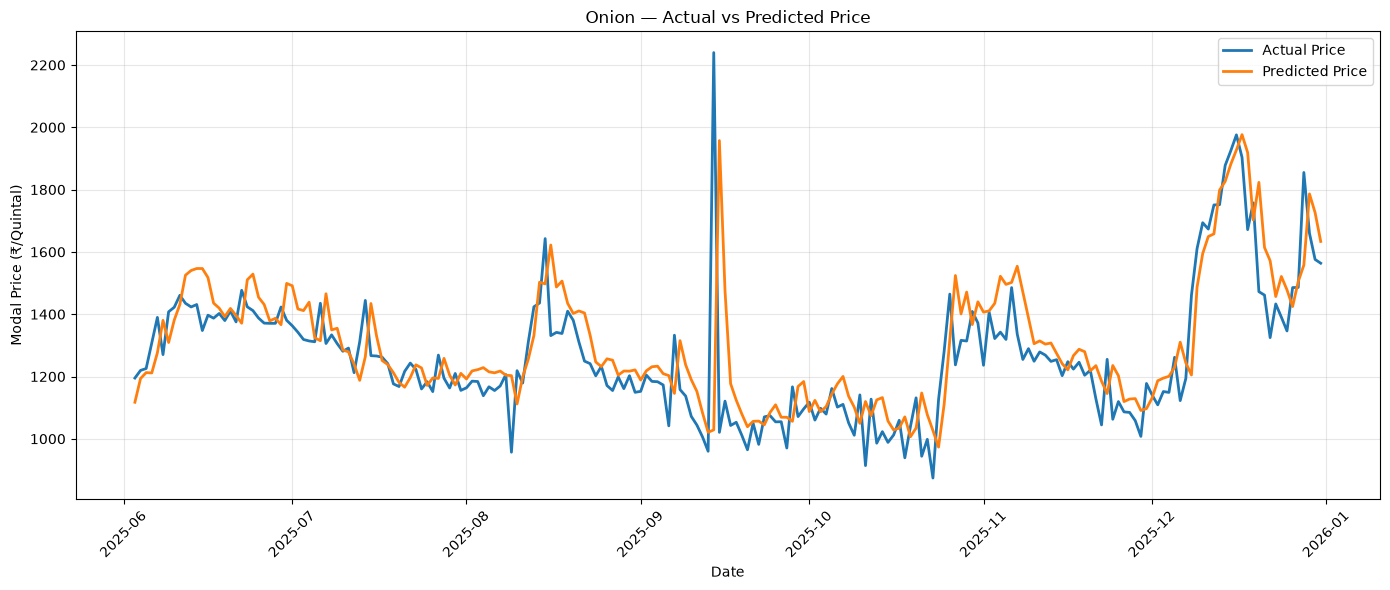

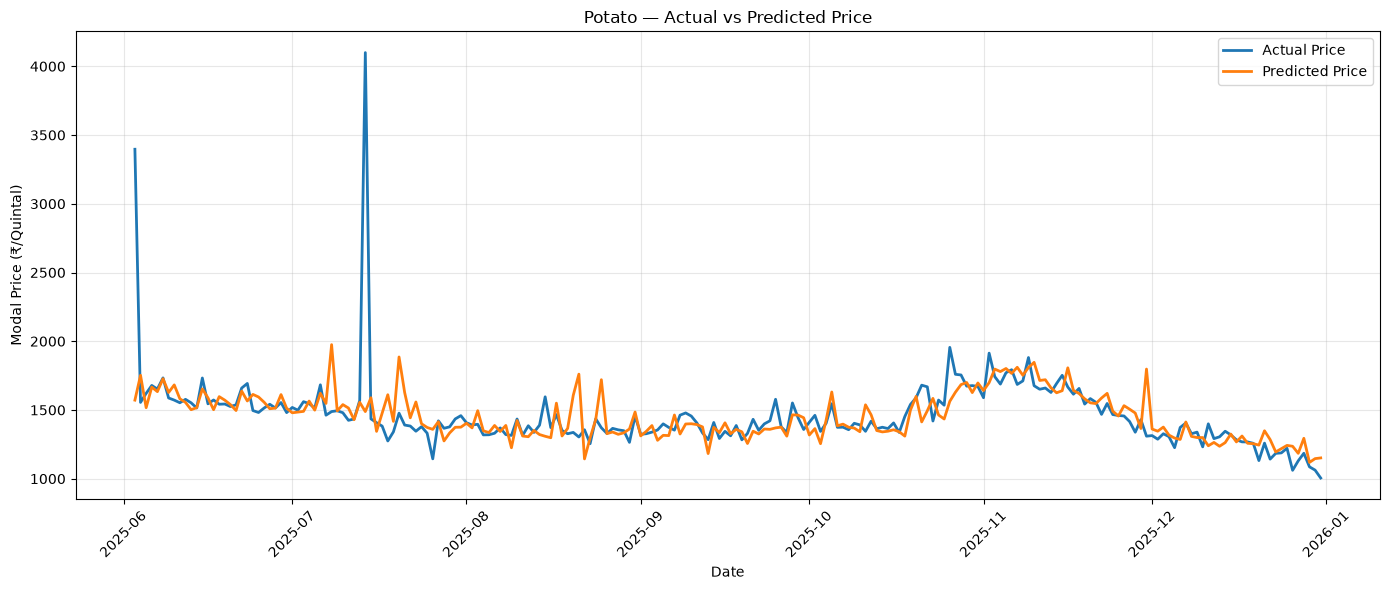

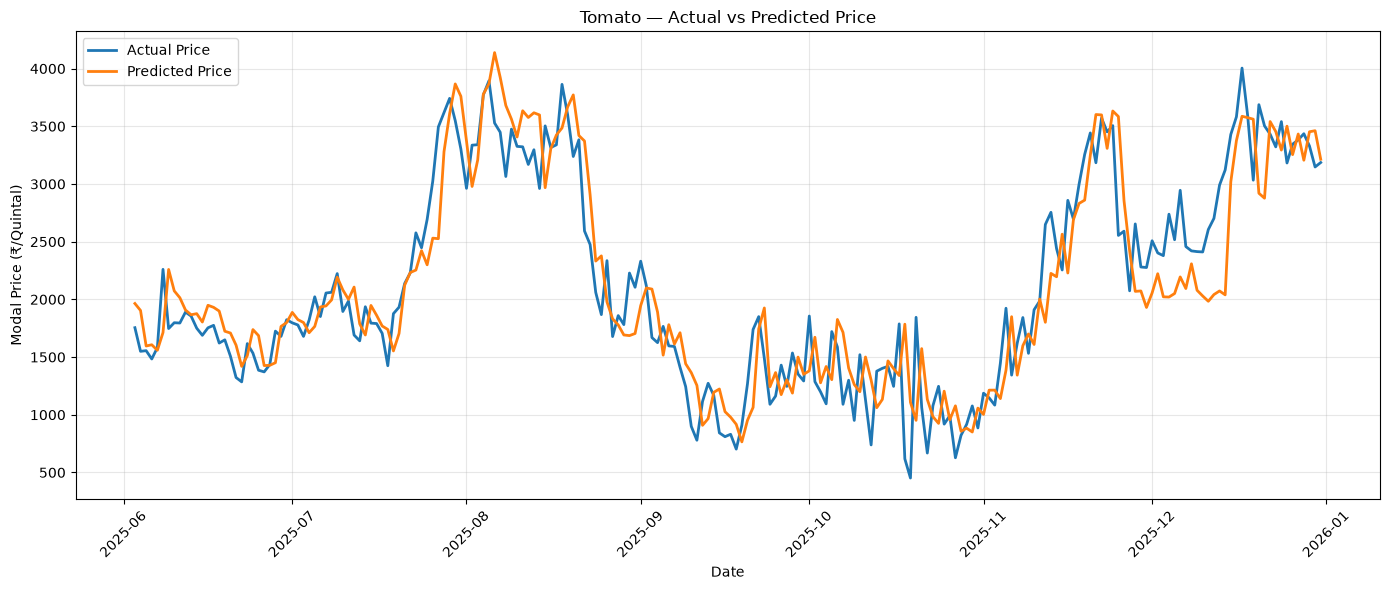

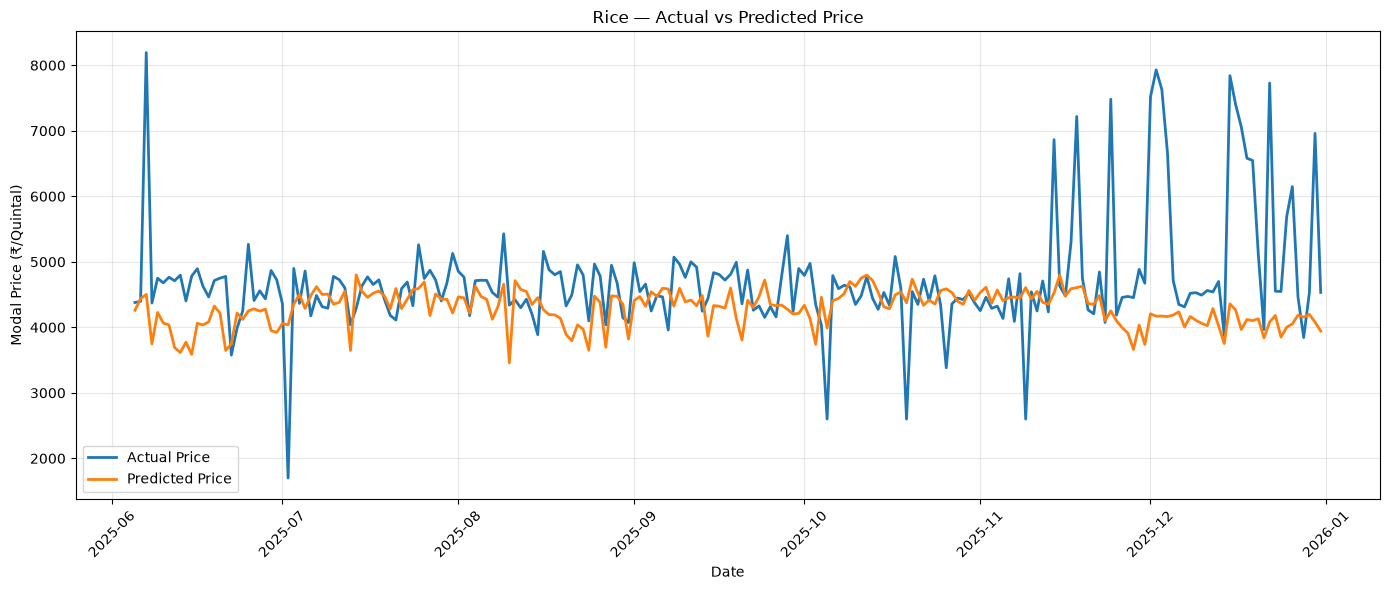

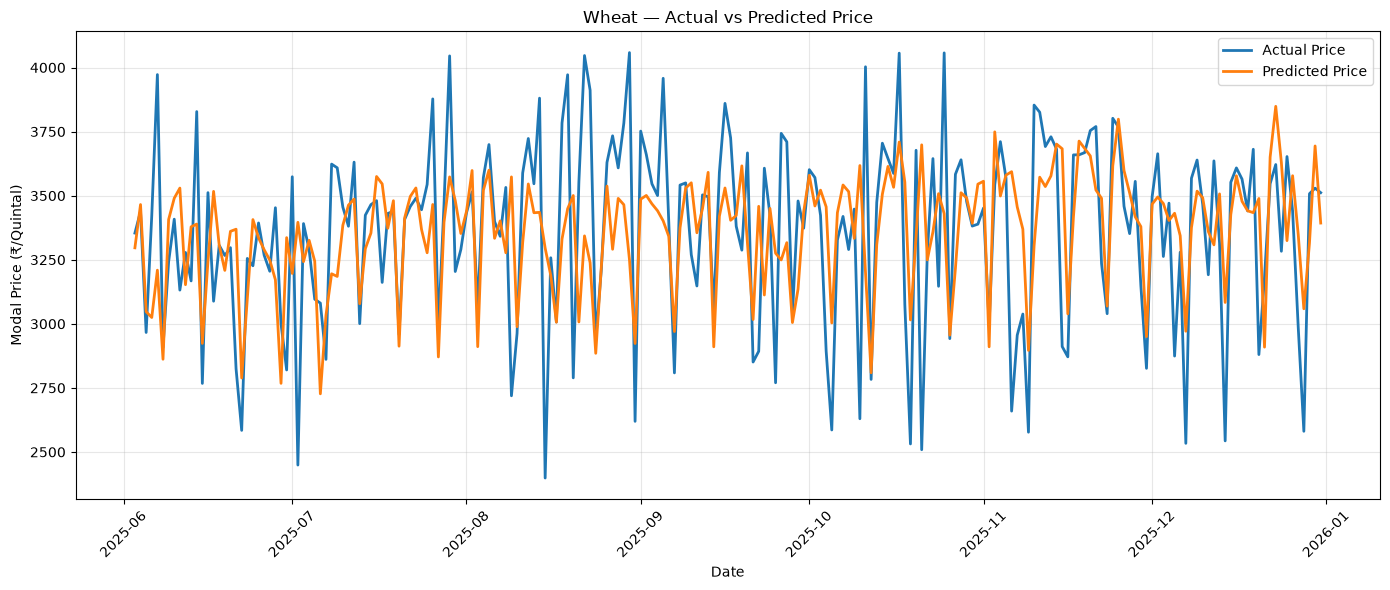

In [31]:
# ==============================================================
# STEP 9 — ACTUAL VS PREDICTED PRICE
# ==============================================================

import matplotlib.pyplot as plt

for commodity in commodities:

    actual = y_test[commodity]
    predicted = predictions[commodity]
    dates = test_dates[commodity]

    plt.figure(figsize=(14, 6))

    plt.plot(
        dates,
        actual.values,
        label="Actual Price",
        linewidth=2
    )

    plt.plot(
        dates,
        predicted,
        label="Predicted Price",
        linewidth=2
    )

    plt.title(
        f"{commodity} — Actual vs Predicted Price"
    )

    plt.xlabel("Date")
    plt.ylabel("Modal Price (₹/Quintal)")

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [32]:
print("Models:")
print(models.keys())

print("\nCommodities:")
print(commodities)

print("\nFeature data:")
print(feature_data.keys())

Models:
dict_keys(['Onion', 'Potato', 'Tomato', 'Rice', 'Wheat'])

Commodities:
['Onion', 'Potato', 'Tomato', 'Rice', 'Wheat']

Feature data:
dict_keys(['Onion', 'Potato', 'Tomato', 'Rice', 'Wheat'])


In [33]:
# ==============================================================
# STEP 10 — NEXT 30-DAY PRICE FORECAST
# ==============================================================

import pandas as pd
import numpy as np

forecast_results = {}

for commodity in commodities:

    print("=" * 60)
    print("FORECASTING:", commodity)
    print("=" * 60)

    # ----------------------------------------------------------
    # Get commodity data
    # ----------------------------------------------------------
    data = feature_data[commodity].copy()

    data["Date"] = pd.to_datetime(data["Date"])

    data = data.sort_values("Date").reset_index(drop=True)

    # ----------------------------------------------------------
    # Get trained model
    # ----------------------------------------------------------
    model = models[commodity]

    # ----------------------------------------------------------
    # Get latest historical information
    # ----------------------------------------------------------
    history = list(data["Modal_Price"].values)

    last_date = data["Date"].iloc[-1]

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )

    future_predictions = []

    # ----------------------------------------------------------
    # Recursive 30-day forecasting
    # ----------------------------------------------------------

    for future_date in future_dates:

        # Need at least 30 previous prices
        if len(history) < 30:
            raise ValueError(
                f"Not enough historical prices for {commodity}"
            )

        # -----------------------------
        # Lag features
        # -----------------------------

        lag_1 = history[-1]
        lag_2 = history[-2]
        lag_3 = history[-3]
        lag_7 = history[-7]
        lag_14 = history[-14]
        lag_30 = history[-30]

        # -----------------------------
        # Rolling features
        # -----------------------------

        rolling_7 = np.mean(history[-7:])
        rolling_30 = np.mean(history[-30:])

        # -----------------------------
        # Calendar features
        # -----------------------------

        month = future_date.month
        day = future_date.day
        day_of_week = future_date.dayofweek
        quarter = future_date.quarter

        # -----------------------------
        # Create feature row
        # -----------------------------

        X_future = pd.DataFrame([{
            "Lag_1": lag_1,
            "Lag_2": lag_2,
            "Lag_3": lag_3,
            "Lag_7": lag_7,
            "Lag_14": lag_14,
            "Lag_30": lag_30,
            "Rolling_7": rolling_7,
            "Rolling_30": rolling_30,
            "Day": day,
            "Month": month,
            "DayOfWeek": day_of_week,
            "Quarter": quarter
        }])

        # Make sure feature order matches training
        X_future = X_future[features]

        # -----------------------------
        # Predict
        # -----------------------------

        prediction = model.predict(X_future)[0]

        # Prevent negative prices
        prediction = max(0, prediction)

        future_predictions.append(prediction)

        # Add prediction to history
        # This allows next day's forecast
        # to use today's predicted price.
        history.append(prediction)

    # ----------------------------------------------------------
    # Save forecast
    # ----------------------------------------------------------

    forecast_df = pd.DataFrame({
        "Date": future_dates,
        "Commodity": commodity,
        "Predicted_Price": future_predictions
    })

    forecast_results[commodity] = forecast_df

    print(forecast_df.to_string(index=False))

FORECASTING: Onion
      Date Commodity  Predicted_Price
2026-01-01     Onion      1479.402344
2026-01-02     Onion      1465.227295
2026-01-03     Onion      1470.133423
2026-01-04     Onion      1528.112671
2026-01-05     Onion      1497.802246
2026-01-06     Onion      1504.001709
2026-01-07     Onion      1505.834839
2026-01-08     Onion      1412.582886
2026-01-09     Onion      1360.492676
2026-01-10     Onion      1347.538574
2026-01-11     Onion      1330.564697
2026-01-12     Onion      1333.094482
2026-01-13     Onion      1324.259521
2026-01-14     Onion      1322.475098
2026-01-15     Onion      1355.286865
2026-01-16     Onion      1302.485229
2026-01-17     Onion      1266.998413
2026-01-18     Onion      1270.120972
2026-01-19     Onion      1208.321167
2026-01-20     Onion      1156.388794
2026-01-21     Onion      1116.897095
2026-01-22     Onion      1100.069092
2026-01-23     Onion      1099.054321
2026-01-24     Onion      1123.200928
2026-01-25     Onion      1141.

Feature importance

In [34]:
# ==============================================================
# STEP 10B — COMBINE ALL 5 COMMODITY FORECASTS
# ==============================================================

all_forecasts = pd.concat(
    forecast_results.values(),
    ignore_index=True
)

print("=" * 70)
print("30-DAY PRICE FORECAST — ALL COMMODITIES")
print("=" * 70)

print(all_forecasts.to_string(index=False))

30-DAY PRICE FORECAST — ALL COMMODITIES
      Date Commodity  Predicted_Price
2026-01-01     Onion      1479.402344
2026-01-02     Onion      1465.227295
2026-01-03     Onion      1470.133423
2026-01-04     Onion      1528.112671
2026-01-05     Onion      1497.802246
2026-01-06     Onion      1504.001709
2026-01-07     Onion      1505.834839
2026-01-08     Onion      1412.582886
2026-01-09     Onion      1360.492676
2026-01-10     Onion      1347.538574
2026-01-11     Onion      1330.564697
2026-01-12     Onion      1333.094482
2026-01-13     Onion      1324.259521
2026-01-14     Onion      1322.475098
2026-01-15     Onion      1355.286865
2026-01-16     Onion      1302.485229
2026-01-17     Onion      1266.998413
2026-01-18     Onion      1270.120972
2026-01-19     Onion      1208.321167
2026-01-20     Onion      1156.388794
2026-01-21     Onion      1116.897095
2026-01-22     Onion      1100.069092
2026-01-23     Onion      1099.054321
2026-01-24     Onion      1123.200928
2026-01-25

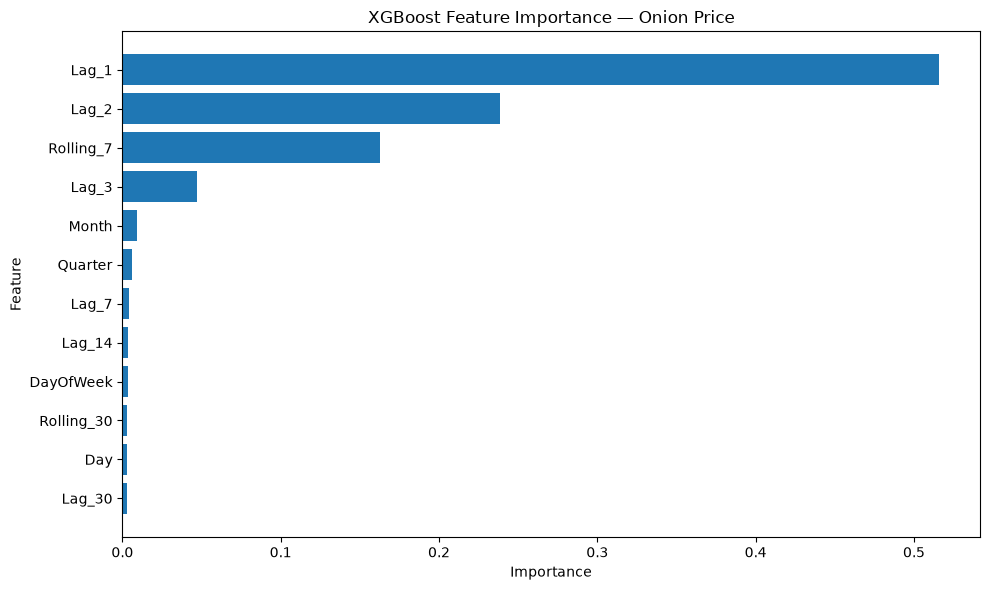

In [14]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance — Onion Price")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Save the trained model

In [35]:
# ==============================================================
# STEP 10C — SAVE FORECAST RESULTS
# ==============================================================

all_forecasts.to_csv(
    "xgboost_30_day_price_forecast.csv",
    index=False
)

print("Forecast saved successfully.")
print("File: xgboost_30_day_price_forecast.csv")

Forecast saved successfully.
File: xgboost_30_day_price_forecast.csv
